In [10]:
from datasets import load_dataset
import pandas as pd
import numpy as np

ds = load_dataset("howardzhao3/train24", "default", split="train")

print(ds)
print(ds[0])

Dataset({
    features: ['site_id', 'direction', 'year', 'month', 'day', 'hour', 'lat_x', 'lon', 'count', 'obs_count', 'time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration', 'site_nr', 'long', 'lat_y', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'dist_nearest_station', 'dist_nearest_school', 'school_count', 'station_count', 'park_count', 'description'],
    num_rows: 2419098
})
{'site_id': 1, 'direction': 'in', 'year': 2024, 'month': 1, 'day': 1, 'hour': 0, 'lat_x': 50.916183, 'lon': 4.456122, 'count': 0.0, 'obs_count': 4, 'time': '2024-01-01 00:00:00', 'temperature_2m': 7.85, 'apparent_temperature': 0.9682741, 'relative_humidity_2m': 72.43961, 'precipitation': 0.0, 'rain': 0.0, 'snowfall': 0.0, 'wind_speed_10m': 10.104455, 'shortwave_radiation': 0.0, 'direct_normal_irradiance': 0.0, 'sunshine_duration': 0.0, '

In [3]:
df = ds.to_pandas()
print(df.shape)
print(df.columns.tolist())
df.head()

(2419098, 37)
['site_id', 'direction', 'year', 'month', 'day', 'hour', 'lat_x', 'lon', 'count', 'obs_count', 'time', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration', 'site_nr', 'long', 'lat_y', 'naam', 'domein', 'wegnr', 'district', 'gemeente', 'interval', 'datum_van', 'dist_nearest_station', 'dist_nearest_school', 'school_count', 'station_count', 'park_count', 'description']


,site_id,direction,year,month,day,hour,lat_x,lon,count,obs_count,...,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description
0,1,in,2024,1,1,0,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
1,1,in,2024,1,1,1,50.916183,4.456122,3.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
2,1,in,2024,1,1,2,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
3,1,in,2024,1,1,3,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
4,1,in,2024,1,1,4,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo


In [6]:
df_2024 = df.copy()
if "year" in df_2024.columns:
    df_2024 = df_2024[df_2024["year"] == 2024].copy()

# Create date column if year/month/day columns exist
if all(col in df_2024.columns for col in ["year", "month", "day"]):
    df_2024["date_dt"] = pd.to_datetime(
        df_2024[["year", "month", "day"]],
        errors="coerce"
    )
else:
    print("No year/month/day columns found. Check your date column manually.")

# Create day-of-week and weekend flag
df_2024["day_of_week"] = df_2024["date_dt"].dt.dayofweek
df_2024["is_weekend_binary"] = df_2024["day_of_week"].isin([5, 6]).astype(int)

# Rush hour flag
if "hour" in df_2024.columns:
    df_2024["is_rush_hour"] = df_2024["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
else:
    print("No hour column found. Rush-hour features will not be correct.")
    df_2024["is_rush_hour"] = 0

# Make sure count is numeric
df_2024["count"] = pd.to_numeric(df_2024["count"], errors="coerce")


In [7]:
print(df_2024.shape)
df_2024.head()

(2419098, 41)


,site_id,direction,year,month,day,hour,lat_x,lon,count,obs_count,...,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description,date_dt,day_of_week,is_weekend_binary,is_rush_hour
0,1,in,2024,1,1,0,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
1,1,in,2024,1,1,1,50.916183,4.456122,3.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
2,1,in,2024,1,1,2,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
3,1,in,2024,1,1,3,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0
4,1,in,2024,1,1,4,50.916183,4.456122,0.0,4,...,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo,2024-01-01,0,0,0


In [8]:
cluster_unit = "site_id"

if cluster_unit not in df_2024.columns:
    print("site_id column not found. Available columns are:")
    print(df_2024.columns.tolist())

In [11]:
df_2024["weekday_count"] = np.where(
    df_2024["is_weekend_binary"] == 0,
    df_2024["count"],
    np.nan
)

df_2024["weekend_count"] = np.where(
    df_2024["is_weekend_binary"] == 1,
    df_2024["count"],
    np.nan
)

df_2024["rush_hour_count"] = np.where(
    df_2024["is_rush_hour"] == 1,
    df_2024["count"],
    np.nan
)

In [12]:
#aggregate data by sites
agg_dict = {
    # cycling volume
    "mean_count": ("count", "mean"),
    "median_count": ("count", "median"),
    "max_count": ("count", "max"),
    "std_count": ("count", "std"),

    # temporal behaviour
    "weekday_mean": ("weekday_count", "mean"),
    "weekend_mean": ("weekend_count", "mean"),
    "rush_hour_mean": ("rush_hour_count", "mean"),
}

# Add weather columns only if they exist
optional_features = {
    "mean_temperature": "temperature_2m",
    "mean_precipitation": "precipitation",
    "mean_wind": "wind_speed_10m",
    "mean_solar": "shortwave_radiation",
    "mean_humidity": "relative_humidity_2m",

    # spatial infrastructure
    "park_count": "park_count",
    "school_count": "school_count",
    "station_count": "station_count",
    "dist_nearest_station": "dist_nearest_station",
    "dist_nearest_school": "dist_nearest_school",

    # mapping columns
    "lat": "lat_x",
    "lon": "lon",
}

for new_name, old_col in optional_features.items():
    if old_col in df_2024.columns:
        agg_dict[new_name] = (old_col, "mean")

# Add municipality/gemeente label if available
if "gemeente" in df_2024.columns:
    agg_dict["gemeente"] = ("gemeente", "first")

site_cluster_df = df_2024.groupby(cluster_unit).agg(**agg_dict).reset_index()

site_cluster_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,mean_solar,mean_humidity,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,124.834130,80.685045,0.0,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,123.896403,80.977477,0.0,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,123.896403,80.977477,0.0,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,123.720515,80.552367,0.0,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,123.720515,80.552367,0.0,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen


In [13]:
site_cluster_df["weekend_weekday_ratio"] = (
    site_cluster_df["weekend_mean"] / (site_cluster_df["weekday_mean"] + 1e-6)
)

site_cluster_df["rush_regular_ratio"] = (
    site_cluster_df["rush_hour_mean"] / (site_cluster_df["mean_count"] + 1e-6)
)

site_cluster_df["count_variability"] = (
    site_cluster_df["std_count"] / (site_cluster_df["mean_count"] + 1e-6)
)

site_cluster_df = site_cluster_df.replace([np.inf, -np.inf], np.nan)

site_cluster_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,school_count,station_count,dist_nearest_station,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,0.0,0.0,2762.772259,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,0.0,0.0,4223.596605,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,0.0,0.0,4283.438956,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,1.0,0.0,2936.036400,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,1.0,0.0,2929.505988,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971


In [43]:
# Remove inactive / zero-count sites before clustering
active_sites_df = site_cluster_df[
    (site_cluster_df["mean_count"] > 0) &
    (site_cluster_df["max_count"] > 0)
].copy()

print("Before filtering:", site_cluster_df.shape)
print("After filtering:", active_sites_df.shape)

active_sites_df.head()

Before filtering: (140, 27)
After filtering: (136, 27)


,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability,cluster,PC1,PC2
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892,0,-0.001244,-0.028004
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661,0,1.269161,0.352182
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981,0,0.982051,0.519545
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634,0,-1.644815,1.543719
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971,0,-1.364291,1.405748


In [46]:
clustering_features_clean = [
    "mean_count",
    "median_count",
    "max_count",
    "std_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean",
    "weekend_weekday_ratio",
    "rush_regular_ratio",
    "count_variability",
    "park_count",
    "school_count",
    "station_count",
    "dist_nearest_station",
    "dist_nearest_school"
]

clustering_features_clean = [
    col for col in clustering_features_clean
    if col in active_sites_df.columns
]

print("Final clustering features:")
print(clustering_features_clean)

Final clustering features:
['mean_count', 'median_count', 'max_count', 'std_count', 'weekday_mean', 'weekend_mean', 'rush_hour_mean', 'weekend_weekday_ratio', 'rush_regular_ratio', 'count_variability', 'park_count', 'school_count', 'station_count', 'dist_nearest_station', 'dist_nearest_school']


In [47]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

X_active = active_sites_df[clustering_features_clean].copy()
X_active = X_active.replace([np.inf, -np.inf], np.nan)

count_like_features = [
    "mean_count",
    "median_count",
    "max_count",
    "std_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean"
]

X_active_transformed = X_active.copy()

for col in count_like_features:
    if col in X_active_transformed.columns:
        X_active_transformed[col] = np.log1p(X_active_transformed[col])

imputer = SimpleImputer(strategy="median")
X_active_imputed = imputer.fit_transform(X_active_transformed)

scaler = StandardScaler()
X_active_scaled = scaler.fit_transform(X_active_imputed)

print(X_active_scaled.shape)

(136, 15)


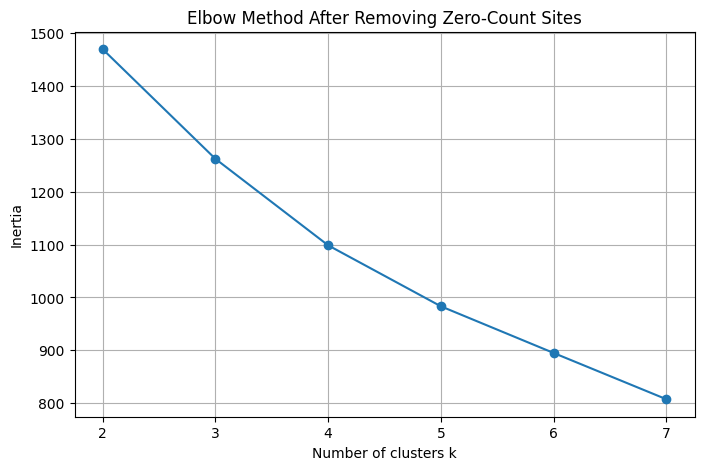

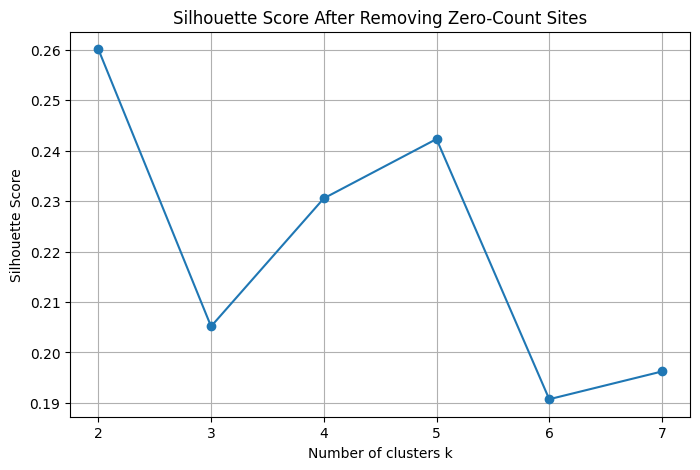

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_active_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_active_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method After Removing Zero-Count Sites")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score After Removing Zero-Count Sites")
plt.grid(True)
plt.show()

In [49]:
best_k = 2

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

site_cluster_df["cluster"] = final_kmeans.fit_predict(X_scaled)

site_cluster_df.head()

,site_id,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,mean_temperature,mean_precipitation,...,dist_nearest_school,lat,lon,gemeente,weekend_weekday_ratio,rush_regular_ratio,count_variability,cluster,PC1,PC2
0,1,8.394581,5.0,67.0,8.914139,9.287691,6.144631,15.245902,11.758942,0.116291,...,1036.993839,50.916183,4.456122,Machelen,0.661589,1.816160,1.061892,1,-0.001244,-0.028004
1,2,16.595856,4.0,259.0,28.788188,19.301924,9.778646,31.885018,11.737836,0.131398,...,1004.367360,51.275120,4.471690,Brasschaat,0.506615,1.921264,1.734661,0,1.269161,0.352182
2,3,15.415813,2.0,248.0,27.439863,17.824268,9.348357,30.094490,11.737836,0.131398,...,1041.580638,51.275030,4.472220,Brasschaat,0.524474,1.952183,1.779981,1,0.982051,0.519545
3,4,3.782445,0.0,105.0,6.894015,3.932252,3.405048,6.005464,11.739435,0.135587,...,788.693562,51.160230,5.190110,Balen,0.865928,1.587720,1.822634,1,-1.644815,1.543719
4,5,3.940574,1.0,100.0,7.191435,4.074109,3.604167,6.266166,11.739435,0.135587,...,785.493710,51.160180,5.190030,Balen,0.884651,1.590165,1.824971,1,-1.364291,1.405748


In [50]:
active_sites_df["cluster"].value_counts().sort_index()

cluster
0    83
1    53
Name: count, dtype: int64

In [51]:
cluster_summary = (
    active_sites_df
    .groupby("cluster")[clustering_features_clean]
    .mean()
    .round(2)
)

cluster_summary

,mean_count,median_count,max_count,std_count,weekday_mean,weekend_mean,rush_hour_mean,weekend_weekday_ratio,rush_regular_ratio,count_variability,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school
cluster,,,,,,,,,,,,,,,
0,5.18,1.18,185.23,9.94,5.73,3.80,9.01,0.71,1.73,2.13,0.59,0.53,0.00,2477.77,1111.31
1,19.55,9.53,572.64,29.70,21.22,15.32,34.40,0.74,1.77,1.69,2.98,3.30,0.21,1283.88,668.95


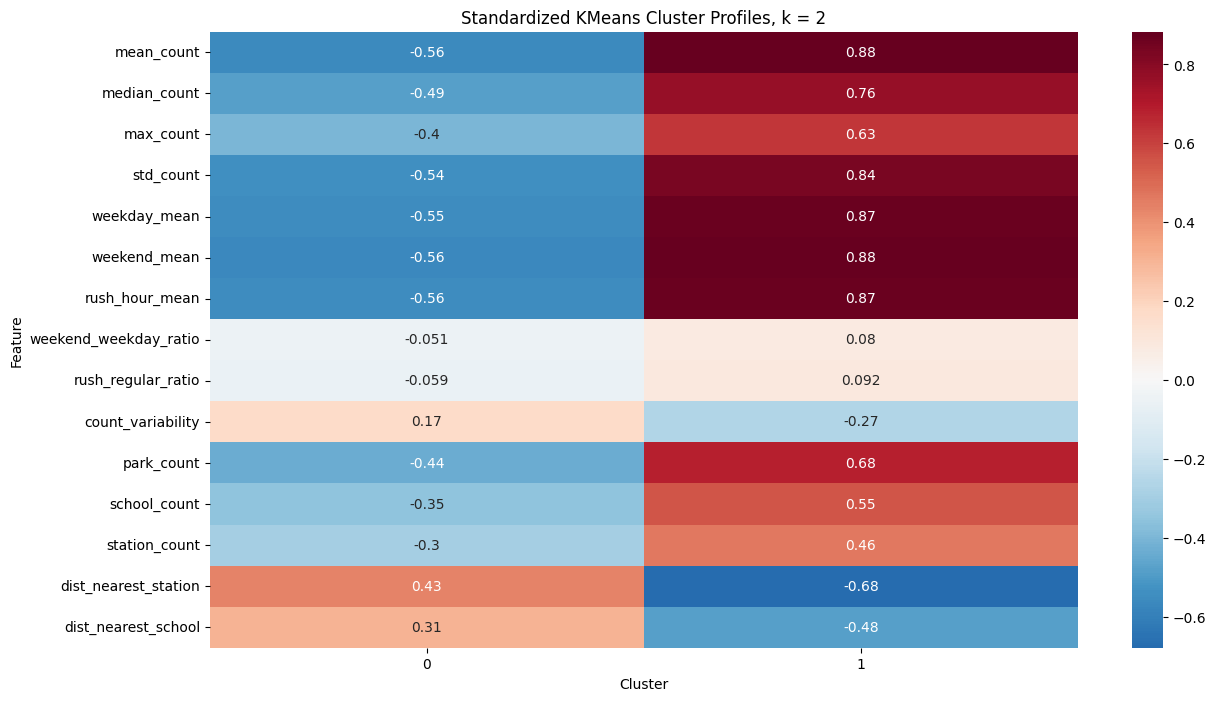

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df = pd.DataFrame(
    X_active_scaled,
    columns=clustering_features_clean
)

scaled_df["cluster"] = active_sites_df["cluster"].values

scaled_cluster_summary = scaled_df.groupby("cluster").mean()

plt.figure(figsize=(14, 8))
sns.heatmap(
    scaled_cluster_summary.T,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Standardized KMeans Cluster Profiles, k = 2")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.show()

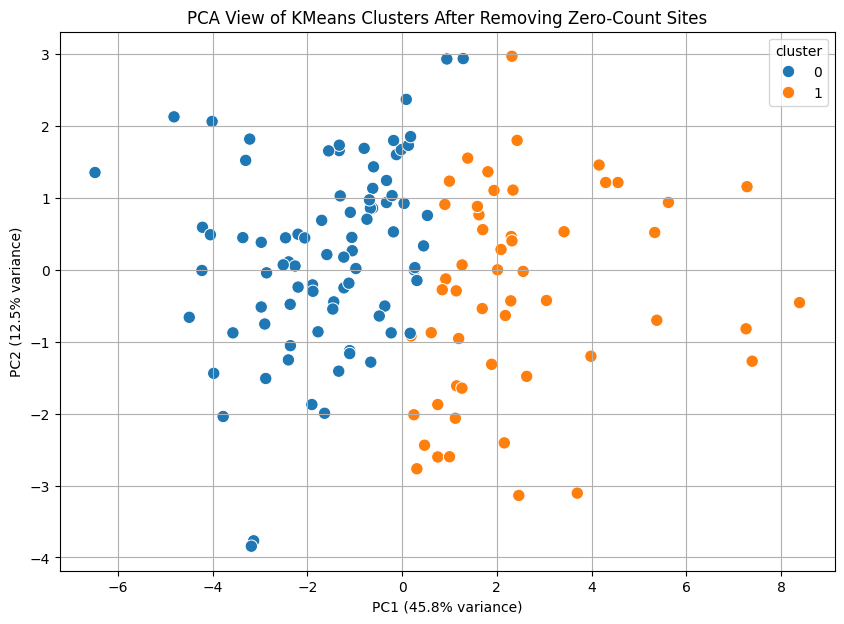

In [53]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_active_scaled)

active_sites_df["PC1"] = pca_result[:, 0]
active_sites_df["PC2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=active_sites_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=80
)

plt.title("PCA View of KMeans Clusters After Removing Zero-Count Sites")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.grid(True)
plt.show()

/tmp/ipykernel_5978/497855935.py:20: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


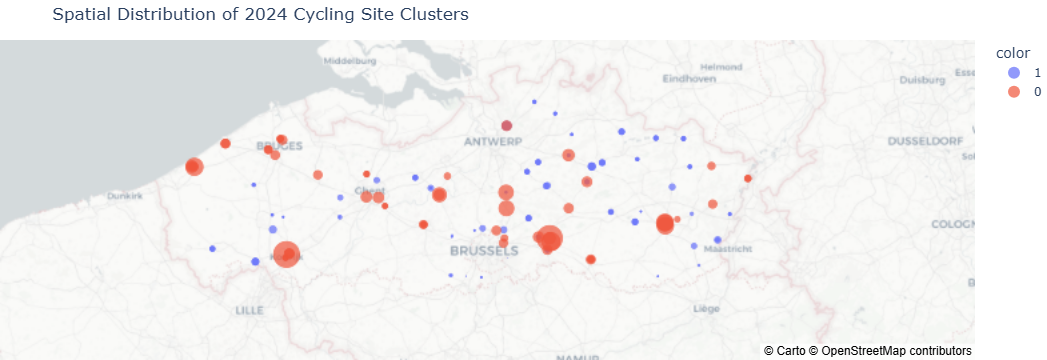

In [54]:
import plotly.express as px

if "lat" in site_cluster_df.columns and "lon" in site_cluster_df.columns:

    hover_cols = [
        col for col in [
            cluster_unit,
            "gemeente",
            "mean_count",
            "weekday_mean",
            "weekend_mean",
            "rush_hour_mean",
            "park_count",
            "school_count",
            "station_count"
        ]
        if col in site_cluster_df.columns
    ]

    fig = px.scatter_mapbox(
        site_cluster_df,
        lat="lat",
        lon="lon",
        color=site_cluster_df["cluster"].astype(str),
        size="mean_count",
        hover_data=hover_cols,
        zoom=7,
        mapbox_style="carto-positron",
        title="Spatial Distribution of 2024 Cycling Site Clusters"
    )

    fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
    fig.show()

else:
    print("Latitude/longitude columns not available for mapping.")

In [56]:
cluster_labels = {
    0: "Lower-activity / peripheral sites",
    1: "Higher-activity / infrastructure-supported sites"
}

active_sites_df["cluster_label"] = active_sites_df["cluster"].map(cluster_labels)

active_sites_df[["site_id", "cluster", "cluster_label", "mean_count", "park_count", "school_count", "station_count"]].head()

,site_id,cluster,cluster_label,mean_count,park_count,school_count,station_count
0,1,0,Lower-activity / peripheral sites,8.394581,0.0,0.0,0.0
1,2,0,Lower-activity / peripheral sites,16.595856,0.0,0.0,0.0
2,3,0,Lower-activity / peripheral sites,15.415813,0.0,0.0,0.0
3,4,0,Lower-activity / peripheral sites,3.782445,0.0,1.0,0.0
4,5,0,Lower-activity / peripheral sites,3.940574,0.0,1.0,0.0


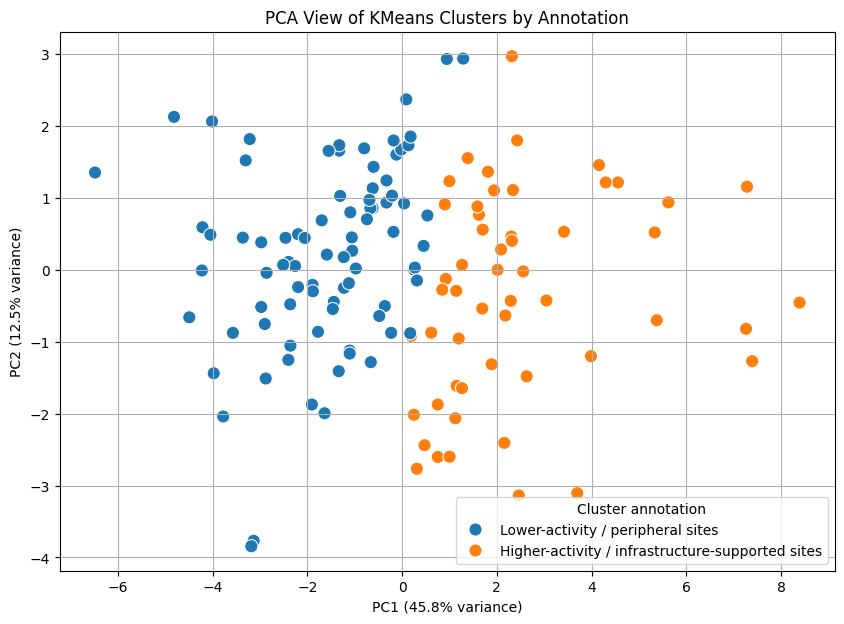

In [57]:


pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_active_scaled)

active_sites_df["PC1"] = pca_result[:, 0]
active_sites_df["PC2"] = pca_result[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=active_sites_df,
    x="PC1",
    y="PC2",
    hue="cluster_label",
    s=90
)

plt.title("PCA View of KMeans Clusters by Annotation")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Cluster annotation")
plt.grid(True)
plt.show()

In [58]:
cluster_info = active_sites_df[
    ["site_id", "cluster", "cluster_label"]
].copy()

df_clustered = df_2024.merge(
    cluster_info,
    on="site_id",
    how="inner"
)

df_clustered.shape

(2368048, 46)

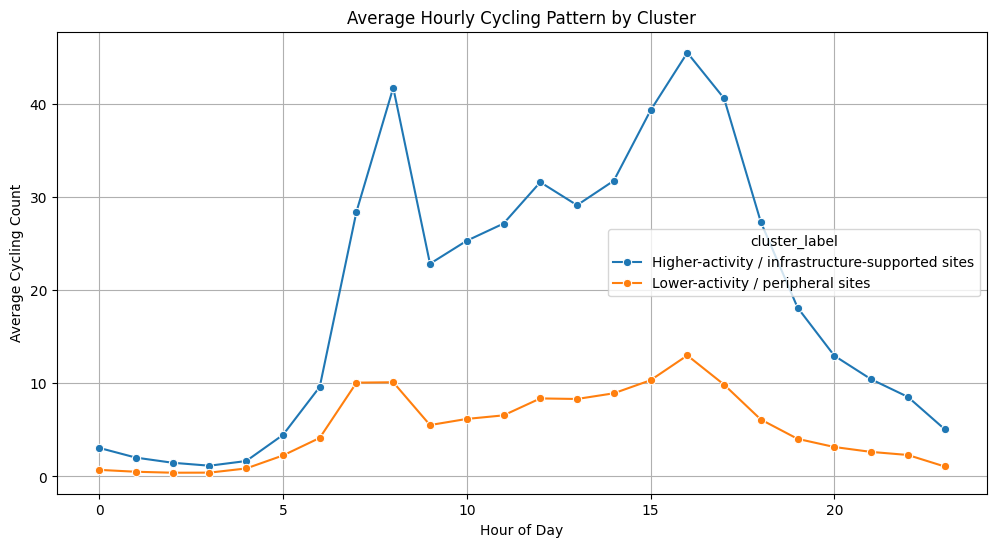

In [60]:
hourly_profile = (
    df_clustered
    .groupby(["cluster_label", "hour"])["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_profile,
    x="hour",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Average Hourly Cycling Pattern by Cluster")
plt.xlabel("Hour of Day")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

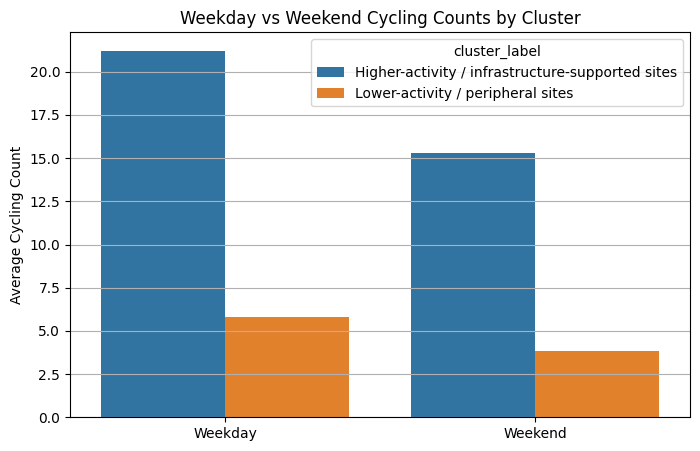

In [61]:
weekday_profile = (
    df_clustered
    .groupby(["cluster_label", "is_weekend_binary"])["count"]
    .mean()
    .reset_index()
)

weekday_profile["day_type"] = weekday_profile["is_weekend_binary"].map({
    0: "Weekday",
    1: "Weekend"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weekday_profile,
    x="day_type",
    y="count",
    hue="cluster_label"
)

plt.title("Weekday vs Weekend Cycling Counts by Cluster")
plt.xlabel("")
plt.ylabel("Average Cycling Count")
plt.grid(axis="y")
plt.show()

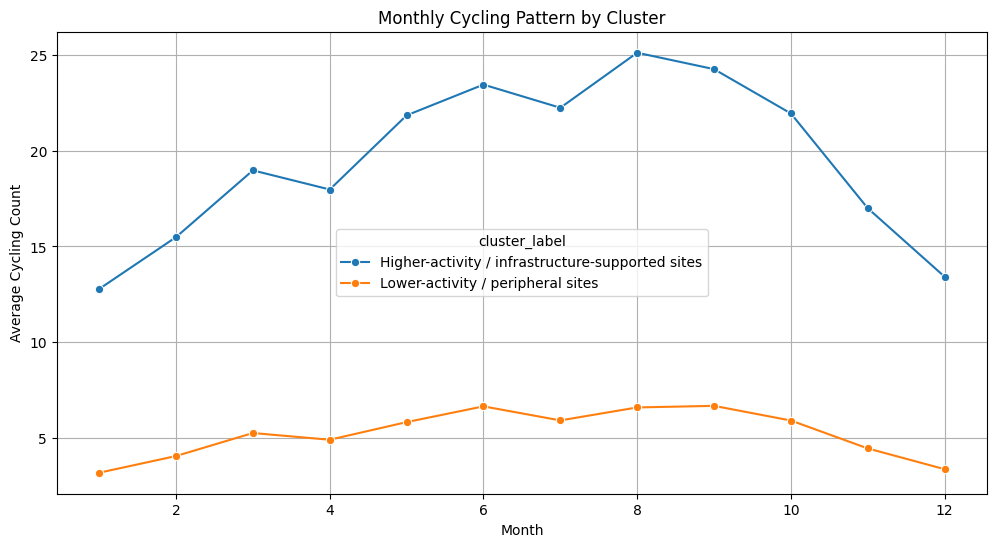

In [62]:
monthly_profile = (
    df_clustered
    .groupby(["cluster_label", "month"])["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_profile,
    x="month",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Monthly Cycling Pattern by Cluster")
plt.xlabel("Month")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

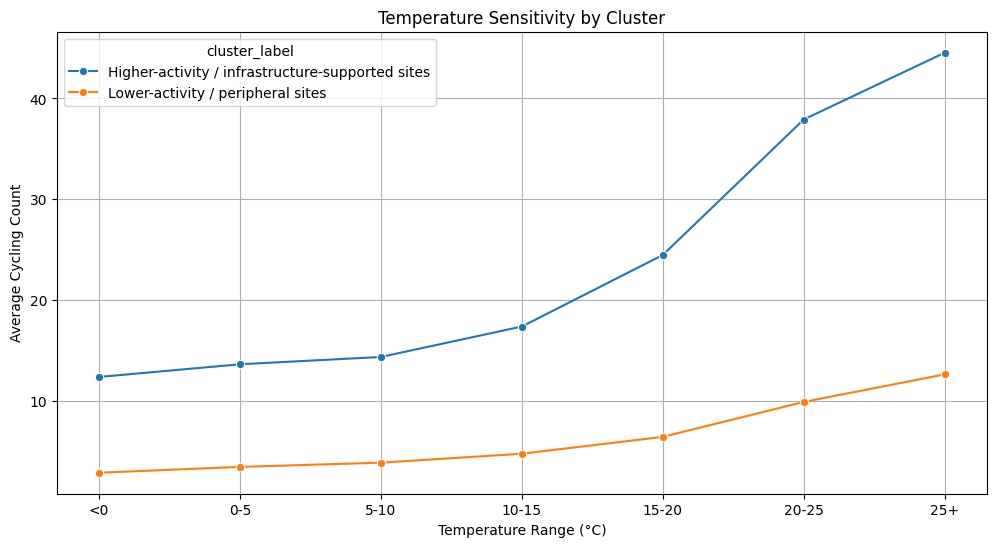

In [63]:
df_clustered["temperature_bin"] = pd.cut(
    df_clustered["temperature_2m"],
    bins=[-10, 0, 5, 10, 15, 20, 25, 35],
    labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", "25+"]
)

temp_profile = (
    df_clustered
    .groupby(["cluster_label", "temperature_bin"], observed=True)["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=temp_profile,
    x="temperature_bin",
    y="count",
    hue="cluster_label",
    marker="o"
)

plt.title("Temperature Sensitivity by Cluster")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Average Cycling Count")
plt.grid(True)
plt.show()

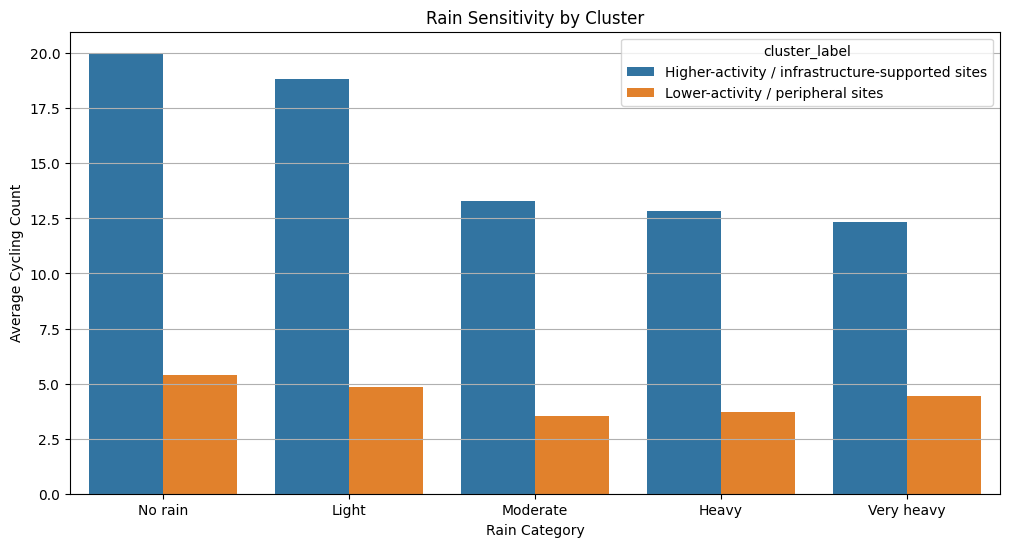

In [64]:
df_clustered["rain_category"] = pd.cut(
    df_clustered["precipitation"],
    bins=[-0.01, 0, 1, 3, 10, 100],
    labels=["No rain", "Light", "Moderate", "Heavy", "Very heavy"]
)

rain_profile = (
    df_clustered
    .groupby(["cluster_label", "rain_category"], observed=True)["count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=rain_profile,
    x="rain_category",
    y="count",
    hue="cluster_label"
)

plt.title("Rain Sensitivity by Cluster")
plt.xlabel("Rain Category")
plt.ylabel("Average Cycling Count")
plt.grid(axis="y")
plt.show()

In [65]:
representative_sites = (
    active_sites_df
    .sort_values(["cluster", "mean_count"], ascending=[True, False])
    .groupby("cluster")
    .head(5)
)

representative_sites[
    ["site_id", "cluster_label", "mean_count", "weekday_mean", "weekend_mean", 
     "rush_hour_mean", "park_count", "school_count", "station_count"]
]

,site_id,cluster_label,mean_count,weekday_mean,weekend_mean,rush_hour_mean,park_count,school_count,station_count
1,2,Lower-activity / peripheral sites,16.595856,19.301924,9.778646,31.885018,0.0,0.0,0.0
2,3,Lower-activity / peripheral sites,15.415813,17.824268,9.348357,30.094490,0.0,0.0,0.0
111,112,Lower-activity / peripheral sites,10.809995,13.083492,5.082532,14.800319,0.0,0.0,0.0
126,127,Lower-activity / peripheral sites,10.179133,12.434001,4.498598,14.717213,0.0,0.0,0.0
83,84,Lower-activity / peripheral sites,10.175603,11.485926,6.874599,19.875911,0.0,0.0,0.0
139,143,Higher-activity / infrastructure-supported sites,90.070014,99.965013,65.142228,160.357696,12.0,4.0,0.0
106,107,Higher-activity / infrastructure-supported sites,86.822291,95.233540,65.632412,159.028233,0.0,7.0,0.0
68,69,Higher-activity / infrastructure-supported sites,47.373008,54.816396,28.621394,90.230191,6.0,25.0,0.0
63,64,Higher-activity / infrastructure-supported sites,43.915699,40.938534,51.415865,60.178962,3.0,3.0,0.0
135,137,Higher-activity / infrastructure-supported sites,42.263604,46.215410,32.308093,72.055783,1.0,8.0,0.0


In [66]:
infra_summary = (
    active_sites_df
    .groupby("cluster_label")[
        ["park_count", "school_count", "station_count", 
         "dist_nearest_station", "dist_nearest_school"]
    ]
    .mean()
    .round(2)
)

infra_summary

,park_count,school_count,station_count,dist_nearest_station,dist_nearest_school
cluster_label,,,,,
Higher-activity / infrastructure-supported sites,2.98,3.30,0.21,1283.88,668.95
Lower-activity / peripheral sites,0.59,0.53,0.00,2477.77,1111.31


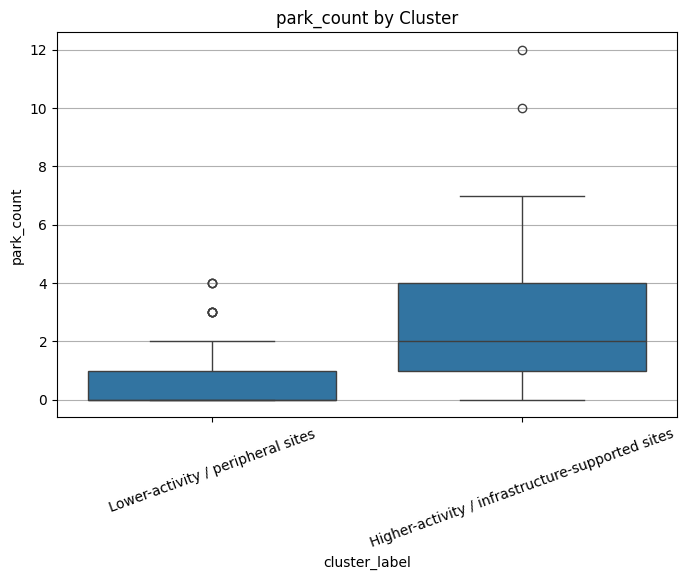

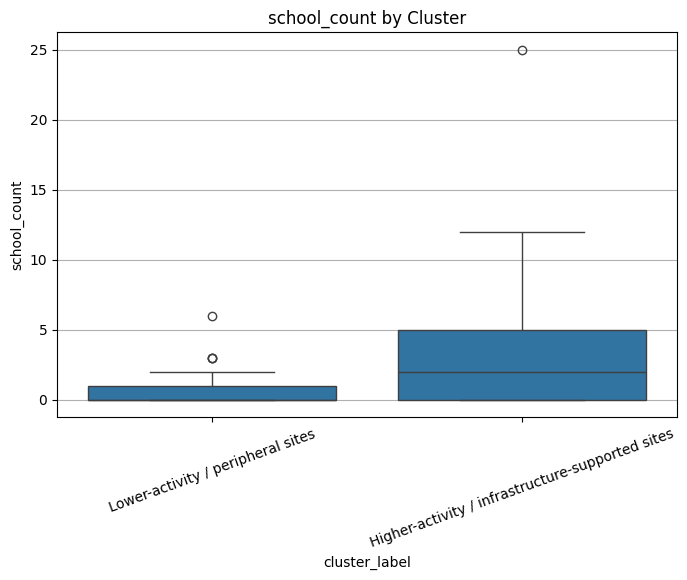

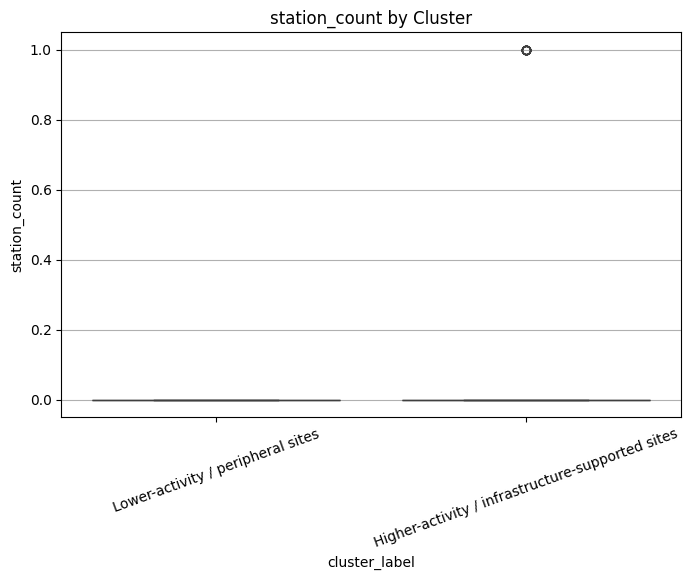

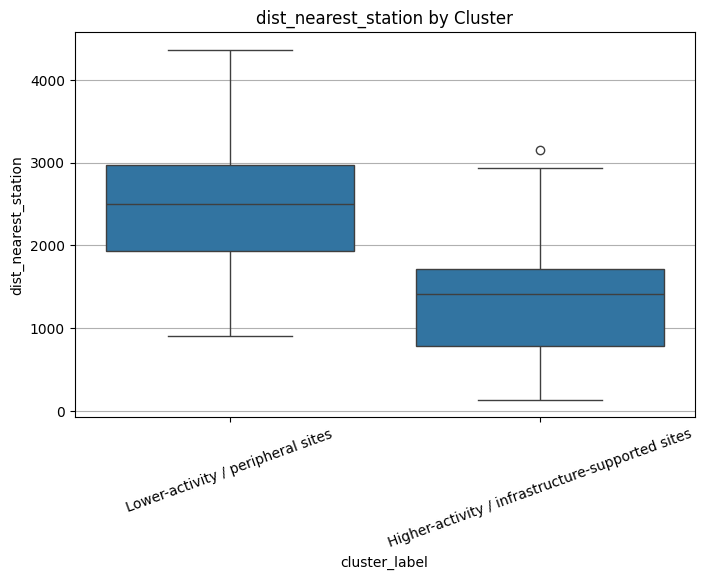

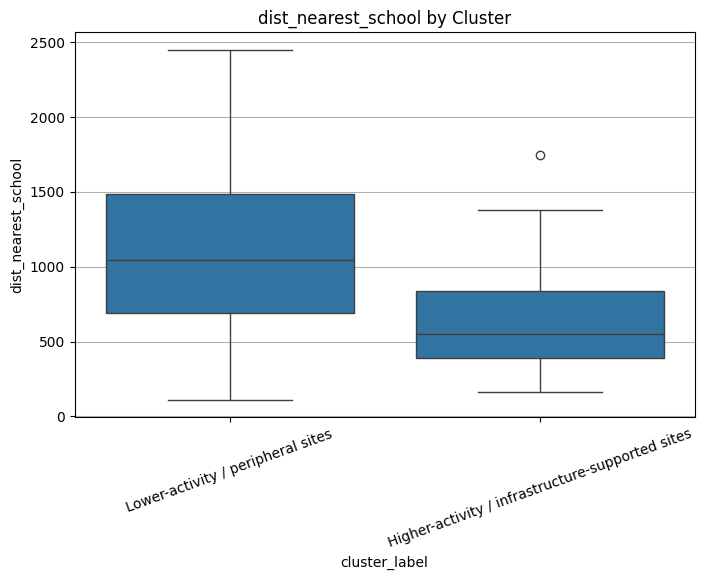

In [67]:
infra_features = [
    "park_count",
    "school_count",
    "station_count",
    "dist_nearest_station",
    "dist_nearest_school"
]

for feature in infra_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=active_sites_df,
        x="cluster_label",
        y=feature
    )
    plt.title(f"{feature} by Cluster")
    plt.xticks(rotation=20)
    plt.grid(axis="y")
    plt.show()

In [71]:
# Save final 2024 KMeans model clearly
kmeans_2024 = final_kmeans

# Save final 2024 clustered site dataframe clearly
active_sites_2024 = active_sites_df.copy()

active_sites_2024["cluster_2024"] = active_sites_2024["cluster"]
active_sites_2024["cluster_label_2024"] = active_sites_2024["cluster_label"]

active_sites_2024[[
    "site_id",
    "cluster_2024",
    "cluster_label_2024",
    "mean_count",
    "weekday_mean",
    "weekend_mean",
    "rush_hour_mean"
]].head()

,site_id,cluster_2024,cluster_label_2024,mean_count,weekday_mean,weekend_mean,rush_hour_mean
0,1,0,Lower-activity / peripheral sites,8.394581,9.287691,6.144631,15.245902
1,2,0,Lower-activity / peripheral sites,16.595856,19.301924,9.778646,31.885018
2,3,0,Lower-activity / peripheral sites,15.415813,17.824268,9.348357,30.094490
3,4,0,Lower-activity / peripheral sites,3.782445,3.932252,3.405048,6.005464
4,5,0,Lower-activity / peripheral sites,3.940574,4.074109,3.604167,6.266166


In [72]:
print("2024 model clusters:", kmeans_2024.n_clusters)

active_sites_2024["cluster_label_2024"].value_counts()

2024 model clusters: 2


cluster_label_2024
Lower-activity / peripheral sites                   83
Higher-activity / infrastructure-supported sites    53
Name: count, dtype: int64

In [73]:
required_objects = [
    "active_sites_2024",
    "kmeans_2024",
    "imputer",
    "scaler",
    "clustering_features_clean",
    "count_like_features"
]

for obj in required_objects:
    print(obj, "exists" if obj in globals() else "MISSING")

active_sites_2024 exists
kmeans_2024 exists
imputer exists
scaler exists
clustering_features_clean exists
count_like_features exists


In [75]:

from datasets import load_dataset, DatasetDict
ds_all = load_dataset("MDA-Project-Group3/combined_dataset")

print(ds_all)

# Handle DatasetDict or single Dataset
if isinstance(ds_all, DatasetDict):
    ds = ds_all["train"]
else:
    ds = ds_all

print(ds)
print(ds.column_names)

DatasetDict({
    train: Dataset({
        features: ['site_id', 'direction', 'start_time', 'end_time', 'count', 'lat', 'lon', 'site_name', 'municipality', 'road_code', 'awv_code', 'install_date', 'direction_label', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
        num_rows: 30830936
    })
})
Dataset({
    features: ['site_id', 'direction', 'start_time', 'end_time', 'count', 'lat', 'lon', 'site_name', 'municipality', 'road_code', 'awv_code', 'install_date', 'direction_label', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
    num_rows: 30830936
})
['site_id', 'direction', 'start_time', 'end_time', 'count', 'lat', 'lon', 'site_name', 'municipality', 'road_code', 'awv_code', 'install_date', 'direction_label', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'is_weekend', 'hour_sin', 

In [ ]:
# Filter at Hugging Face dataset level before converting to pandas
ds_2025 = ds.filter(
    lambda row: row["year"] == 2025,
    num_proc=4
)

print(ds_2025)

df_2025 = ds_2025.to_pandas()

print(df_2025.shape)
df_2025.head()

Filter (num_proc=4):   0%|          | 0/30830936 [00:00<?, ? examples/s]

Dataset({
    features: ['site_id', 'direction', 'start_time', 'end_time', 'count', 'lat', 'lon', 'site_name', 'municipality', 'road_code', 'awv_code', 'install_date', 'direction_label', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
    num_rows: 9908890
})
